✅ RAPIDS cuML & Libraries detected (GPU Acceleration Enabled)

--- Step 1: Locating Data ---
✅ Found input file at: /kaggle/input/sentence-embeddings-dataset/sentence_embeddings.parquet
📄 File Size: 7.12 GB

--- Step 2: Loading Embeddings ---
Attempting to read with PyArrow...
Loaded 4,682,238 sentences.
Stacking vectors into memory...
Moving data to GPU...
GPU Data Shape: (4682238, 384)

--- Step 3: Running PCA (384 -> 50 dims) ---
Reduced Data Shape: (4682238, 50)

--- Step 4: Running HDBSCAN ---
This will take 15-20 minutes...
✅ Clustering finished in 111.80 minutes.

--- Step 5: Generating Metrics & Visualization ---
Calculating advanced metrics on sample...
Running UMAP for 2D visualization (on sample)...
[2025-11-29 17:43:12.683] [CUML] [info] Building knn graph using brute force
✅ Visualization saved to cluster_visualization.png

--- Step 6: Saving Results ---
Saving sentences and clusters to findsum_clusters.csv...
Calculating and saving cluster centroids to cluster_centroids.c

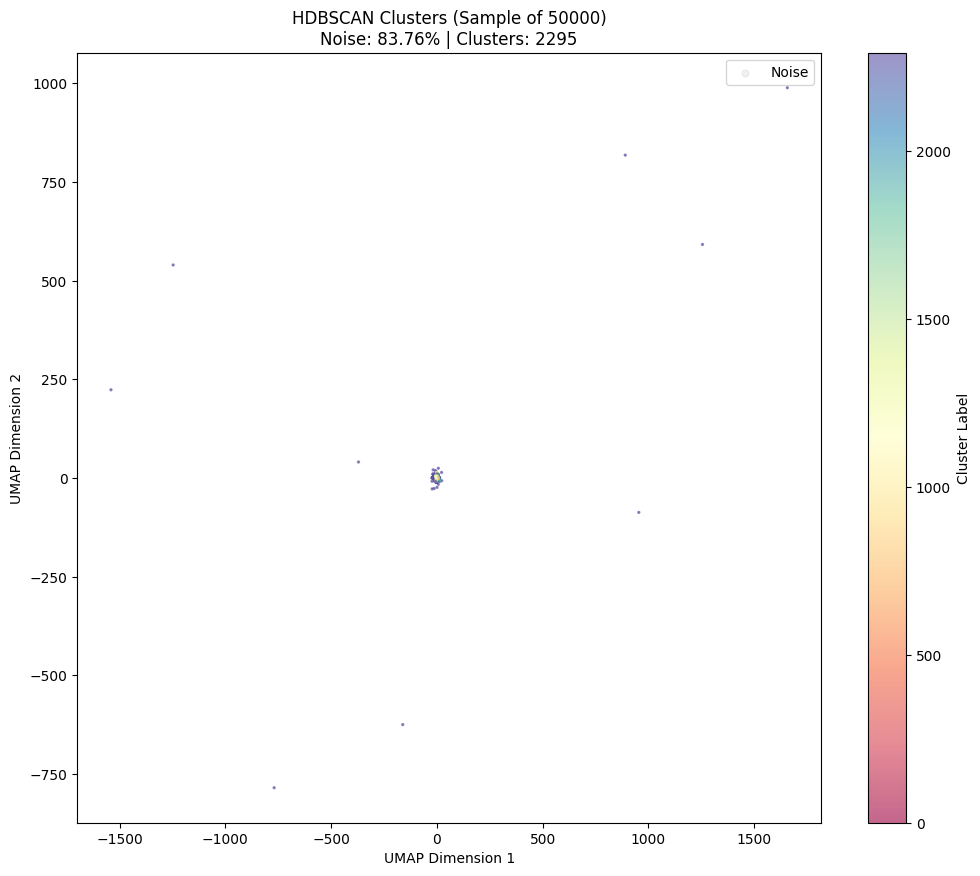

In [1]:
import pandas as pd
import numpy as np
import os
import time
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# --- 1. Auto-Discovery of Input File ---
def find_embeddings_file():
    # Common paths where the file might be
    search_paths = [
        "/kaggle/input/sentence-embeddings-dataset/sentence_embeddings.parquet",
        "/kaggle/working/sentence_embeddings.parquet",
        "sentence_embeddings.parquet"
    ]
    
    # Check explicitly defined paths first
    for path in search_paths:
        if os.path.exists(path):
            return path
            
    # If not found, search the entire /kaggle/input directory
    print("Searching /kaggle/input for .parquet files...")
    for root, dirs, files in os.walk("/kaggle/input"):
        for file in files:
            if file.endswith("sentence_embeddings.parquet"):
                return os.path.join(root, file)
                
    return None

# --- 2. Main Script ---
def main():
    # Check for GPU Libraries
    try:
        import cudf
        from cuml.cluster import HDBSCAN
        from cuml.decomposition import PCA
        from cuml.manifold import UMAP
        from sklearn.metrics import silhouette_score
        print("✅ RAPIDS cuML & Libraries detected (GPU Acceleration Enabled)")
    except ImportError:
        print("❌ ERROR: RAPIDS cuML not found.")
        print("ACTION REQUIRED: Go to Settings -> Accelerator -> Select 'GPU T4 x2'")
        return

    print("\n--- Step 1: Locating Data ---")
    input_file = find_embeddings_file()
    
    if input_file is None:
        print("❌ CRITICAL ERROR: Could not find 'sentence_embeddings.parquet'.")
        print("Please check your Data tab to ensure the dataset is attached.")
        return
        
    # Check file size
    file_size_gb = os.path.getsize(input_file) / (1024**3)
    print(f"✅ Found input file at: {input_file}")
    print(f"📄 File Size: {file_size_gb:.2f} GB")

    print("\n--- Step 2: Loading Embeddings ---")
    start_time = time.time()
    
    df_pd = None
    
    # Attempt 1: Standard PyArrow Read
    try:
        print("Attempting to read with PyArrow...")
        df_pd = pd.read_parquet(input_file, columns=['embedding'])
    except Exception as e_arrow:
        print(f"⚠️ PyArrow failed: {e_arrow}")
        
        # Attempt 2: FastParquet (sometimes handles slightly malformed files better)
        try:
            print("Attempting fallback with FastParquet engine...")
            df_pd = pd.read_parquet(input_file, columns=['embedding'], engine='fastparquet')
        except Exception as e_fast:
            print(f"❌ FastParquet also failed: {e_fast}")
            print("\n🚨 DIAGNOSIS: TRUNCATED FILE")
            print("Even though the file is 1.8GB, it is missing its 'footer' (signature).")
            print("This happens when the kernel runs out of memory or crashes *during* the save process.")
            print("The data is there, but locked in a broken container.")
            print("\nSOLUTION: You must re-run the 'Kaggle Embedding Gen' script.")
            return

    print(f"Loaded {len(df_pd):,} sentences.")

    # --- DEBUG/TESTING: Run on small subset ---
    # Comment out the next two lines to run on the FULL dataset
    # df_pd = df_pd.head(50000) 
    # print(f"⚠️ TESTING MODE: Processing only first {len(df_pd)} rows.")
    # ------------------------------------------
    
    # Convert to float32 numpy array (saves RAM)
    print("Stacking vectors into memory...")
    embeddings = np.stack(df_pd['embedding'].values).astype('float32')
    
    # Clean up CPU memory
    del df_pd
    gc.collect()
    
    # Move to GPU
    print("Moving data to GPU...")
    X_gpu = cudf.DataFrame(embeddings)
    del embeddings
    gc.collect()
    
    print(f"GPU Data Shape: {X_gpu.shape}")
    
    # --- Step 3: Dimensionality Reduction (PCA) ---
    print("\n--- Step 3: Running PCA (384 -> 50 dims) ---")
    pca = PCA(n_components=50)
    X_reduced = pca.fit_transform(X_gpu)
    print(f"Reduced Data Shape: {X_reduced.shape}")
    
    # --- Step 4: Clustering (HDBSCAN) ---
    print("\n--- Step 4: Running HDBSCAN ---")
    print("This will take 15-20 minutes...")
    
    hdb = HDBSCAN(
        min_cluster_size=100, # Increased for full dataset to avoid micro-clusters
        min_samples=15,
        gen_min_span_tree=False,
        verbose=True
    )
    
    clustering_start = time.time()
    clusters = hdb.fit_predict(X_reduced)
    print(f"✅ Clustering finished in {(time.time() - clustering_start)/60:.2f} minutes.")

    # --- Step 5: Metrics & Visualization (New Section) ---
    print("\n--- Step 5: Generating Metrics & Visualization ---")
    
    # Convert GPU labels back to numpy (CPU)
    labels = clusters.to_numpy()
    
    # Basic Counts
    n_clusters = len(np.unique(labels)) - 1 # Subtract 1 for noise (-1)
    noise_count = (labels == -1).sum()
    total_points = len(labels)
    noise_percent = noise_count / total_points * 100
    
    print(f"Calculating advanced metrics on sample...")
    
    # Sampling for Visualization/Metrics (Plotting 4M points is impossible/slow)
    SAMPLE_SIZE = 50000 
    if total_points > SAMPLE_SIZE:
        indices = np.random.choice(total_points, SAMPLE_SIZE, replace=False)
        X_sample_gpu = X_reduced.iloc[indices]
        labels_sample = labels[indices]
    else:
        X_sample_gpu = X_reduced
        labels_sample = labels

    # A. Silhouette Score (Estimated on sample)
    # Move sample to CPU for sklearn metric (cuml has it but sklearn is robust for sampling)
    X_sample_cpu = X_sample_gpu.to_numpy()
    
    try:
        # Only calculate if we have clusters + noise or >1 clusters
        if n_clusters > 0:
            sil_score = silhouette_score(X_sample_cpu, labels_sample, metric='euclidean', sample_size=10000)
            sil_msg = f"{sil_score:.4f} (Estimated on 10k sample)"
        else:
            sil_msg = "N/A (No clusters found)"
    except Exception as e:
        sil_msg = f"Error calculating: {e}"

    # B. UMAP Visualization
    print("Running UMAP for 2D visualization (on sample)...")
    umap = UMAP(n_components=2, n_neighbors=15, min_dist=0.1)
    X_embedded = umap.fit_transform(X_sample_gpu)
    X_embedded_cpu = X_embedded.to_numpy()

    # Plotting
    plt.figure(figsize=(12, 10))
    
    # Plot Noise first (Grey, smaller, transparent)
    noise_mask = labels_sample == -1
    plt.scatter(
        X_embedded_cpu[noise_mask, 0], 
        X_embedded_cpu[noise_mask, 1], 
        c='lightgrey', s=1, alpha=0.3, label='Noise'
    )
    
    # Plot Clusters (colored by label)
    cluster_mask = ~noise_mask
    if cluster_mask.sum() > 0:
        scatter = plt.scatter(
            X_embedded_cpu[cluster_mask, 0], 
            X_embedded_cpu[cluster_mask, 1], 
            c=labels_sample[cluster_mask], 
            cmap='Spectral', s=2, alpha=0.6
        )
        plt.colorbar(scatter, label='Cluster Label')

    plt.title(f"HDBSCAN Clusters (Sample of {SAMPLE_SIZE})\nNoise: {noise_percent:.2f}% | Clusters: {n_clusters}")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    plt.legend(markerscale=5)
    
    plot_filename = "cluster_visualization.png"
    plt.savefig(plot_filename, dpi=150)
    print(f"✅ Visualization saved to {plot_filename}")

    # --- Step 6: Saving Data & Reports ---
    print("\n--- Step 6: Saving Results ---")
    OUTPUT_FILE = "findsum_clusters.csv"
    REPORT_FILE = "cluster_metrics.txt"
    CENTROIDS_FILE = "cluster_centroids.csv"
    
    # A. Save Labeled Data (Includes Text now)
    print(f"Saving sentences and clusters to {OUTPUT_FILE}...")
    # Load original text + IDs
    original_ids = pd.read_parquet(input_file, columns=['doc_id', 'sentence_index', 'sentence'])
    
    # MATCHING SUBSET: Filter original_ids to match the subset we processed
    original_ids = original_ids.head(len(labels))
    
    original_ids['cluster'] = labels
    original_ids.to_csv(OUTPUT_FILE, index=False)
    
    # B. Calculate & Save Centroids (For mapping summaries)
    print(f"Calculating and saving cluster centroids to {CENTROIDS_FILE}...")
    # Convert reduced data to CPU numpy for grouping
    X_reduced_cpu = X_reduced.to_numpy()
    df_pca = pd.DataFrame(X_reduced_cpu)
    df_pca['cluster'] = labels
    
    # Calculate mean vector for each cluster (ignoring noise -1 if desired, but good to keep for ref)
    centroids = df_pca.groupby('cluster').mean()
    centroids.to_csv(CENTROIDS_FILE)
    
    # C. Save Metrics Report
    with open(REPORT_FILE, "w") as f:
        f.write("--- HDBSCAN Clustering Report ---\n")
        f.write(f"Total Sentences: {total_points:,}\n")
        f.write(f"Total Clusters:  {n_clusters}\n")
        f.write(f"Noise Points:    {noise_count:,} ({noise_percent:.2f}%)\n")
        f.write(f"Silhouette Score: {sil_msg}\n")
        f.write("\n--- Cluster Size Statistics (Excluding Noise) ---\n")
        
        # Calculate cluster size stats
        if n_clusters > 0:
            cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
            f.write(f"Smallest Cluster: {cluster_sizes.min()}\n")
            f.write(f"Largest Cluster:  {cluster_sizes.max()}\n")
            f.write(f"Median Cluster:   {cluster_sizes.median()}\n")
            f.write(f"Mean Cluster:     {cluster_sizes.mean():.2f}\n")
        else:
            f.write("No clusters found.\n")

    print(f"SUCCESS! Files generated:")
    print(f"1. Data:      {OUTPUT_FILE} (Contains Sentences + Cluster IDs)")
    print(f"2. Plot:      {plot_filename}")
    print(f"3. Report:    {REPORT_FILE}")
    print(f"4. Centroids: {CENTROIDS_FILE} (Use this to map summary sentences)")
    print(f"\nQuick Metrics:")
    print(f"Clusters: {n_clusters} | Noise: {noise_percent:.2f}% | Silhouette: {sil_msg}")

if __name__ == "__main__":
    main()